In [2]:
from pandas import DataFrame, read_excel, concat
import matplotlib.pyplot as plt
from os import listdir

In [3]:
data = read_excel('toxval/toxval_all_res_toxval_v96_1_ChemIDplus.xlsx')

In [4]:
data

,DTXSID,CASRN,NAME,SOURCE,SUB_SOURCE,TOXVAL_TYPE,TOXVAL_SUBTYPE,TOXVAL_TYPE_SUPERCATEGORY,QUALIFIER,TOXVAL_NUMERIC,...,STRAIN_ORIGINAL,SEX_ORIGINAL,GENERATION_ORIGINAL,LIFESTAGE_ORIGINAL,EXPOSURE_ROUTE_ORIGINAL,EXPOSURE_METHOD_ORIGINAL,EXPOSURE_FORM_ORIGINAL,MEDIA_ORIGINAL,TOXICOLOGICAL_EFFECT_ORIGINAL,ORIGINAL_YEAR
0,DTXSID7020637,50-00-0,Formaldehyde,ChemIDplus,-,LD50,-,Mortality Response Summary Value,=,260.000,...,-,-,-,-,oral,-,-,-,-,-
1,DTXSID7020637,50-00-0,Formaldehyde,ChemIDplus,-,LC50,-,Mortality Response Summary Value,=,454.000,...,-,-,-,-,inhalation,-,-,-,-,-
2,DTXSID7020637,50-00-0,Formaldehyde,ChemIDplus,-,LD50,-,Mortality Response Summary Value,=,42.000,...,-,-,-,-,oral,-,-,-,-,-
3,DTXSID7020637,50-00-0,Formaldehyde,ChemIDplus,-,LD50,-,Mortality Response Summary Value,=,232.470,...,-,-,-,-,dermal,-,-,-,-,-
4,DTXSID7020637,50-00-0,Formaldehyde,ChemIDplus,-,LC50,-,Mortality Response Summary Value,=,0.203,...,-,-,-,-,inhalation,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44272,DTXSID5072933,86770-74-3,"Ethanol, 2-[2-[2-(2-aminoethoxy)ethoxy]ethoxy]-",ChemIDplus,-,LD50,-,Mortality Response Summary Value,>,8000.000,...,-,-,-,-,dermal,-,-,-,-,-
44273,DTXSID2073695,87188-51-0,"Carbonic acid, 1,1-dimethylethyl 4-ethenylphen...",ChemIDplus,-,LD50,-,Mortality Response Summary Value,>,2000.000,...,-,-,-,-,dermal,-,-,-,-,-
44274,DTXSID0046648,112965-21-6,Calcipotriene,ChemIDplus,-,LD50,-,Mortality Response Summary Value,>,15.000,...,-,-,-,-,dermal,-,-,-,-,-
44275,DTXSID10924920,124737-31-1,4-(Dimethylamino)benzene-1-diazonium 2-carboxy...,ChemIDplus,-,LD50,-,Mortality Response Summary Value,=,475.000,...,-,-,-,-,dermal,-,-,-,-,-


In [5]:
data.columns

Index(['DTXSID', 'CASRN', 'NAME', 'SOURCE', 'SUB_SOURCE', 'TOXVAL_TYPE',
       'TOXVAL_SUBTYPE', 'TOXVAL_TYPE_SUPERCATEGORY', 'QUALIFIER',
       'TOXVAL_NUMERIC', 'TOXVAL_UNITS', 'RISK_ASSESSMENT_CLASS', 'STUDY_TYPE',
       'STUDY_DURATION_CLASS', 'STUDY_DURATION_VALUE', 'STUDY_DURATION_UNITS',
       'SPECIES_COMMON', 'STRAIN', 'LATIN_NAME', 'SPECIES_SUPERCATEGORY',
       'SEX', 'GENERATION', 'LIFESTAGE', 'EXPOSURE_ROUTE', 'EXPOSURE_METHOD',
       'EXPOSURE_FORM', 'MEDIA', 'TOXICOLOGICAL_EFFECT', 'EXPERIMENTAL_RECORD',
       'STUDY_GROUP', 'YEAR', 'QC_CATEGORY', 'QC_STATUS', 'SOURCE_HASH',
       'SOURCE_URL', 'SUBSOURCE_URL', 'TOXVAL_TYPE_ORIGINAL',
       'TOXVAL_SUBTYPE_ORIGINAL', 'TOXVAL_NUMERIC_ORIGINAL',
       'TOXVAL_UNITS_ORIGINAL', 'STUDY_TYPE_ORIGINAL',
       'STUDY_DURATION_CLASS_ORIGINAL', 'STUDY_DURATION_VALUE_ORIGINAL',
       'STUDY_DURATION_UNITS_ORIGINAL', 'SPECIES_ORIGINAL', 'STRAIN_ORIGINAL',
       'SEX_ORIGINAL', 'GENERATION_ORIGINAL', 'LIFESTAGE_ORIGINAL'

In [6]:
short_data = concat((
    data['NAME'],
    data['TOXVAL_TYPE'],
    data['TOXVAL_NUMERIC'],
    data['TOXVAL_UNITS'],
    data['SPECIES_COMMON'],
    data['EXPOSURE_ROUTE']
    ), axis=1)
short_data.columns = ['name', 'tox_type', 'value', 'unit', 'animal', 'inj']
short_data

,name,tox_type,value,unit,animal,inj
0,Formaldehyde,LD50,260.000,mg/kg,Guinea Pig,oral
1,Formaldehyde,LC50,454.000,mg/L,Mouse,inhalation
2,Formaldehyde,LD50,42.000,mg/kg,Mouse,oral
3,Formaldehyde,LD50,232.470,mg/kg,Rabbit,dermal
4,Formaldehyde,LC50,0.203,mg/L,Rat,inhalation
...,...,...,...,...,...,...
44272,"Ethanol, 2-[2-[2-(2-aminoethoxy)ethoxy]ethoxy]-",LD50,8000.000,mg/kg,Rabbit,dermal
44273,"Carbonic acid, 1,1-dimethylethyl 4-ethenylphen...",LD50,2000.000,mg/kg,Rabbit,dermal
44274,Calcipotriene,LD50,15.000,mg/kg,Rat,dermal
44275,4-(Dimethylamino)benzene-1-diazonium 2-carboxy...,LD50,475.000,mg/kg,Rat,dermal


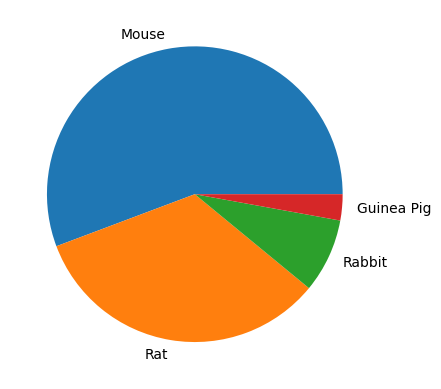

animal
Mouse         24673
Rat           14752
Rabbit         3588
Guinea Pig     1264
Name: count, dtype: int64

In [7]:
x = short_data['animal'].value_counts()
fig = plt.pie(x, labels=x.index)
plt.show()
x

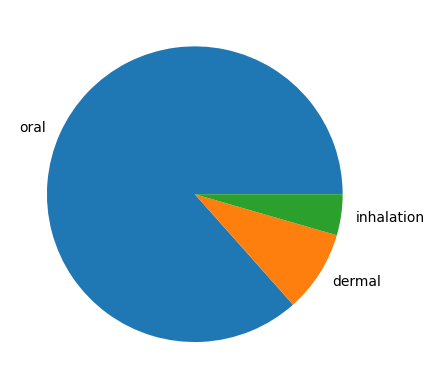

inj
oral          38329
dermal         3965
inhalation     1983
Name: count, dtype: int64

In [8]:
x2 = short_data['inj'].value_counts()
fig2 = plt.pie(x2, labels=x2.index)
plt.show()
x2

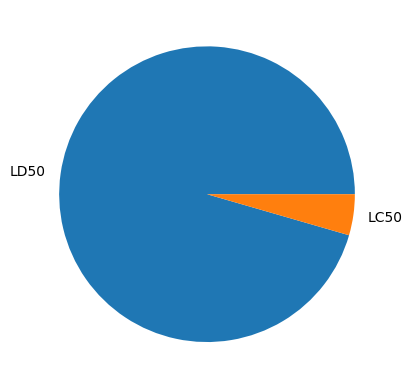

tox_type
LD50    42294
LC50     1983
Name: count, dtype: int64

In [9]:
x2 = short_data['tox_type'].value_counts()
fig2 = plt.pie(x2, labels=x2.index)
plt.show()
x2

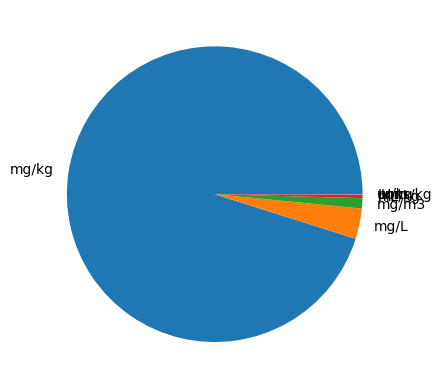

unit
mg/kg       42115
mg/L         1477
mg/m3         495
mL/kg         167
IU/kg          15
ppm             5
units/kg        3
Name: count, dtype: int64

In [10]:
x3 = short_data['unit'].value_counts()
fig3 = plt.pie(x3, labels=x3.index)
plt.show()
x3

In [11]:
toxval_types = DataFrame(columns=['SPECIES_COMMON'])
for file in listdir('./toxval'):
    data = read_excel(f'toxval/{file}')['SPECIES_COMMON']
    toxval_types = concat((toxval_types, data))

toxval_types

,SPECIES_COMMON
0,Rat
1,Human
2,Rat
3,Human
4,Mouse
...,...
1370,Rat
1371,Mouse
1372,Rat
1373,Rabbit


In [12]:
counts = toxval_types.value_counts()
# counts.to_excel(excel_writer='animals.xlsx')
counts

SPECIES_COMMON              
Rat                             115067
Human                            53502
Mouse                            44506
Rabbit                           12334
Dog                              10115
Monkey                            2305
Guinea Pig                        1705
Northern Bobwhite Quail            899
European Rabbit                    369
Pig                                249
Hamster                            245
Chicken                            159
Cat                                124
Japanese Quail                     106
Not specified                      101
Zebra Danio                         69
Primate                             63
Cow Family                          60
Sheep                               47
Quail                               40
Mink                                21
Bird's-foot Trefoils                14
Mouse, Rat                           9
House Mouse                          9
Western European House Mouse       

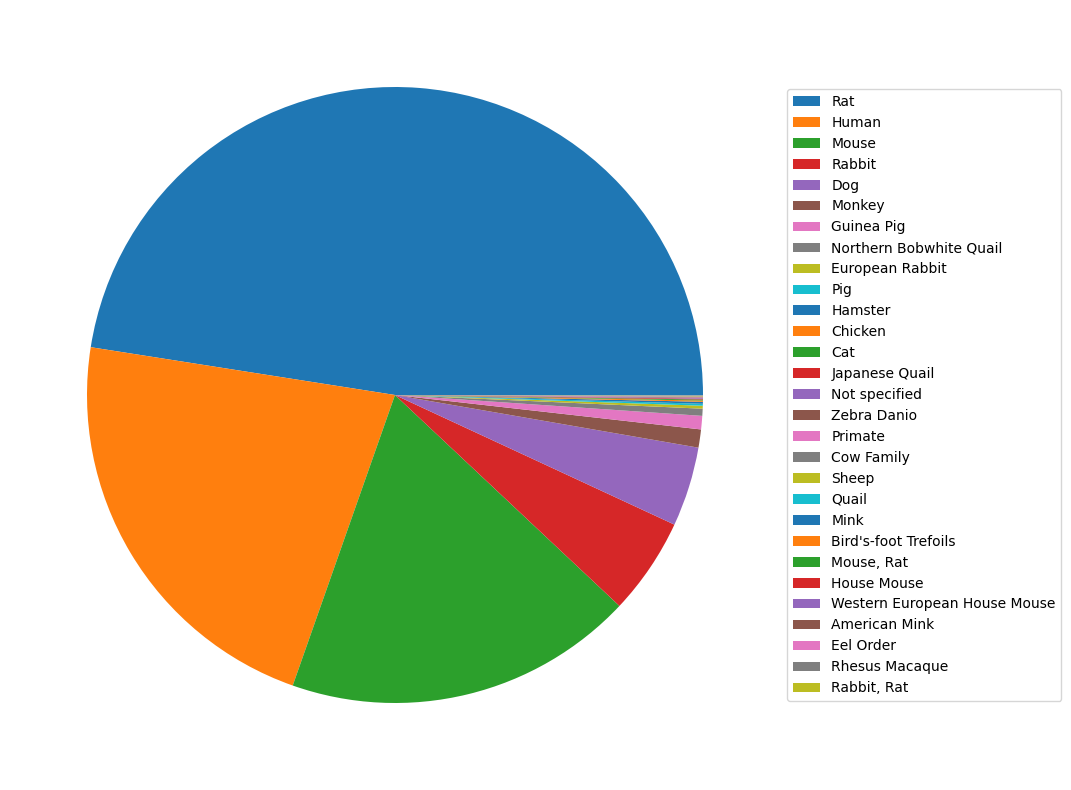

In [13]:
names = [el[0] for el in counts.index.to_list()]
values = [el for el in counts.tolist()]
plt.figure(figsize=(20, 10))
gph = plt.pie(x=values)
plt.legend(names, bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()


<BarContainer object of 29 artists>

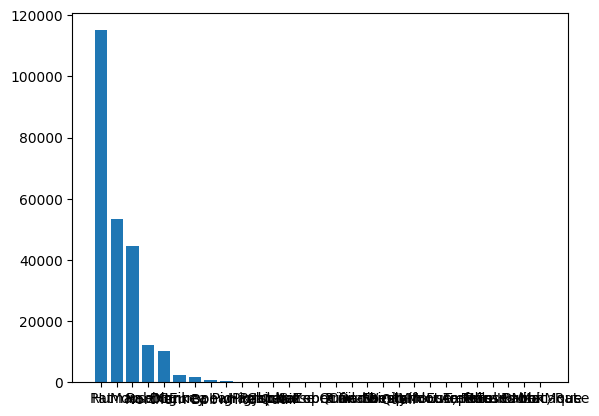

In [14]:
plt.bar(names, values)

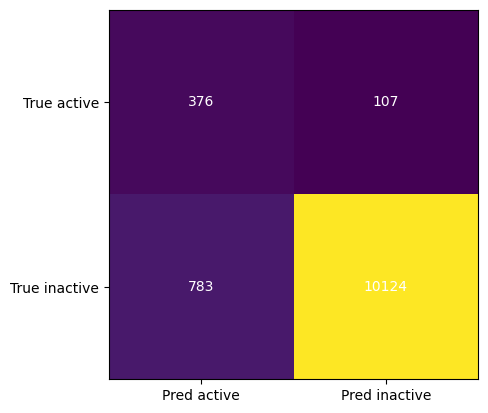

In [15]:
vals = [[376, 107], [783, 10124]]
fig, ax = plt.subplots()
im = ax.imshow(vals)
ax.set_xticks((0, 1), labels=('Pred active', 'Pred inactive'))
ax.set_yticks((0, 1), labels=('True active', 'True inactive'))
text = ax.text(0, 0, 376, ha="center", va="center", color="w")
text = ax.text(0, 1, 783, ha="center", va="center", color="w")
text = ax.text(1, 0, 107, ha="center", va="center", color="w")
text = ax.text(1, 1, 10124, ha="center", va="center", color="w")
plt.show()